# Short straddles: three loss functions against one rank metric

[`06_linear`](06_linear.ipynb) set out the problem this case study exists to teach. A short
at-the-money straddle can earn at most the premium it collected and can lose without bound, so
its return distribution is capped on one side and open on the other. A linear regression fits by
minimizing squared error, which weights an observation by the square of its distance from the
prediction; the information coefficient is a rank correlation, which treats a loss of twenty
percent and a loss of nine thousand percent as adjacent. On this target those two disagree, and
the linear notebook could only pose that as a question, because ordinary least squares has one
loss function and no alternative to compare it against.

**This notebook answers it.** The declared grid fits every capacity setting under three
objectives - squared error, absolute error, and Huber, which behaves like squared error near the
middle of the distribution and like absolute error out in the tail. Nothing else changes: the
same features, the same folds, the same rows, the same metric. If the mismatch between the
fitting loss and the reporting metric is what holds this family back, the objectives should
separate, and they should separate in the order of how much weight each one gives the extremes.

Two further dials come with the model class:

- **Capacity**, set by `num_leaves`: how finely one tree may partition the feature space, and so
  how sharply it can separate the conditions under which the position keeps its premium from
  those where it does not.
- **When to stop**, set by the number of trees. A boosted model has a meaningful state at every
  iteration, so each configuration is scored at ten points along its own training run. Fifteen
  declared configurations at ten checkpoints is 150 candidate models, and **a checkpoint is part
  of a configuration rather than a detail of how it was fitted.**

Two folds, validating on 2019 and 2020 - the second a year in which a short-volatility position
experienced the event it exists to be paid for. Every number below is an average over those two
periods, and the second dominates the tail behaviour the objectives are being compared on.

**Learning objectives.** By the end of this notebook you will be able to:

- Say what a loss function claims about which errors matter, and check that claim against the
  metric a result is judged on.
- Read a comparison of squared error, absolute error and Huber loss on a target with a hard
  ceiling and an unbounded downside, and say what their ordering means.
- Explain why a boosted model produces one result per checkpoint while a linear model produces
  one result in total, and what that implies for counting candidates.
- Read a learning curve of out-of-sample information coefficient against tree count, and say
  whether an apparent peak is a turning point or the highest of ten noisy readings.
- Judge a result by the number of candidates behind it and the amount of validation data under
  it, rather than by its rank in a table.

**Book reference**: Chapter 12, Section 12.2 (GBM libraries) and Section 12.3 (how to tune a
boosted model). Chapter 6, Section 6.7 (Search accounting and run logging) introduces the run
log this notebook writes to.

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb) and
[`04_model_based_features`](04_model_based_features.ipynb) have written the feature matrices,
[`05_evaluation`](05_evaluation.ipynb) has established the walk-forward folds, and
[`06_linear`](06_linear.ipynb) fitted the linear population this one is compared against.

**What it writes**: one training run per configuration and one complete validation prediction
set per configuration and checkpoint, in `run_log/registry.db` and under `run_log/training/` and
`run_log/predictions/`, grouped under a named population.
[`12_backtest`](12_backtest.ipynb) reads that population and selects on validation backtest
Sharpe. **Selection happens there, not here.**

In [1]:
"""Fit the declared short-straddle gradient boosting population on the walk-forward folds."""

import numpy as np
import plotly.graph_objects as go
import polars as pl

from case_studies.research import (
    declared_labels,
    load_model_configs,
    model_requests,
    narrows_declared_catalog,
    open_study,
    resolved_model_plan,
    run_model_population,
)
from utils.style import COLORS, show_plotly_with_alt

In [2]:
LABELS: list[str] = []
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
PREVIEW_REDUCTIONS: dict = {}
CONFIG_NAMES: list[str] = []
POPULATION_NAME = ""

In [3]:
study = open_study("sp500_options", execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None)

## 1. Which labels, and which models

The labels are the same set the linear notebook fitted - the ones `config/setup.yaml` puts in
the sweep, which here is `ret_to_expiry` alone: the return the short straddle earns from the
decision date to expiry. Keeping the set fixed is what makes the two populations comparable;
the families differ, the targets do not. `06_linear` says why `config/training/` holds five
menus when the sweep declares one label.

In [4]:
declared_labels(study, "gbm")

('ret_to_expiry',)

Each declared label's menu at `config/training/{label}.yaml` lists 15 named configurations
under `gbm:`, and each resolves to a preset in `case_studies/config/lgb/`. The grid is a
product of two axes:

- **Five capacity profiles.** `default` uses the library's own leaf count; the rest fix it at 7,
  15, 31 and 63. Leaf count is the direct control on how finely one tree may partition the
  feature space. It is the dial that decides how finely a model can separate the conditions
  under which a short straddle keeps its premium from the ones where it does not.
- **Three objectives.** `mse` minimizes squared error, `mae` absolute error, and `huber` behaves
  like squared error for small residuals and like absolute error beyond a threshold derived from
  each fold's own label spread.

Every configuration runs the same number of boosting iterations with the same learning rate, so
the grid isolates capacity and loss rather than confounding them with training length.

In [5]:
configs = load_model_configs(
    study,
    "gbm",
    labels=LABELS or None,
    config_names=CONFIG_NAMES or None,
)
configs

family,label,config_name,model_class,params
str,str,str,str,str
"""gbm""","""ret_to_expiry""","""leaves_31_mae""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""ret_to_expiry""","""leaves_7_huber""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""ret_to_expiry""","""leaves_7_mae""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""ret_to_expiry""","""leaves_15_mae""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""ret_to_expiry""","""default_mae""","""""","""objective=regression_l1, seed=…"
…,…,…,…,…
"""gbm""","""ret_to_expiry""","""leaves_63_mae""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""ret_to_expiry""","""default_huber""","""""","""objective=huber, seed=42"""
"""gbm""","""ret_to_expiry""","""leaves_63_huber""","""""","""bagging_fraction=0.8, bagging_…"


`LABELS` and `CONFIG_NAMES` both narrow what is fitted, and a narrowed run declares a different
set of members than the canonical population does. A population is immutable once written, so
such a run must publish under its own name, and this says so here rather than several cells
later in a message about hashes.

In [6]:
if narrows_declared_catalog(study, "gbm", configs) and not POPULATION_NAME:
    raise ValueError(
        f"this run declares {configs.height} label-configuration pairs, which is not the "
        f"complete declared catalog, so it cannot publish the canonical population; pass "
        f"POPULATION_NAME to give it its own"
    )

## 2. Binding the declarations to the data

Resolving reads the label and feature files, computes the fold boundaries, works out the exact
rows each fit must predict, and turns any data-dependent parameter into the number it will use.
Huber's threshold is one of those: it is a fraction of the training labels' standard deviation,
so it is a different number on every fold and is resolved from that fold's own data.

Nothing is fitted here, so the plan can be inspected first. Four things to check:

- **`feature_count`, `eligible_entities` and `eligible_rows` agree across every row.** A row that
  differs is a configuration measured on a different sample from its neighbours.
- **`folds` is the same everywhere**, and equals the number of walk-forward splits.
- **`validation_start` and `validation_end` bracket the development sample**, with none of the
  held-out tail visible.
- **`checkpoints` is where this differs from the linear plan.** It is the number of training
  states each configuration will publish predictions for. Multiply it by the number of rows to
  get the number of candidate models this notebook is about to create.

In [7]:
requests = model_requests(
    study,
    configs,
    execution_tier=EXECUTION_TIER,
    preview_reductions=PREVIEW_REDUCTIONS,
)
resolved = tuple(request.resolve() for request in requests)

plan = resolved_model_plan(resolved)
plan.select(
    "config_name",
    "feature_count",
    "eligible_entities",
    "eligible_rows",
    "folds",
    "checkpoints",
    "validation_start",
    "validation_end",
)

config_name,feature_count,eligible_entities,eligible_rows,folds,checkpoints,validation_start,validation_end
str,i64,i64,i64,i64,i64,date,date
"""default_huber""",52,539,132210,2,10,2019-01-07,2020-11-10
"""default_mae""",52,539,132210,2,10,2019-01-07,2020-11-10
"""default_mse""",52,539,132210,2,10,2019-01-07,2020-11-10
"""leaves_15_huber""",52,539,132210,2,10,2019-01-07,2020-11-10
"""leaves_15_mae""",52,539,132210,2,10,2019-01-07,2020-11-10
…,…,…,…,…,…,…,…
"""leaves_63_mae""",52,539,132210,2,10,2019-01-07,2020-11-10
"""leaves_63_mse""",52,539,132210,2,10,2019-01-07,2020-11-10
"""leaves_7_huber""",52,539,132210,2,10,2019-01-07,2020-11-10


## 3. Fitting the population

`run_model_population` fits every resolved request. For one request it walks the folds, and on
each one:

1. takes the rows inside that fold's training window,
2. casts the design matrix to the precision LightGBM works in and leaves missing values in
   place - a tree routes a missing value down its own branch, so imputing a median here would
   hand the model an observation nobody made,
3. fits the declared number of boosting iterations,
4. predicts the fold's validation rows at each checkpoint, using only the trees built up to that
   iteration.

Step 4 is what makes one fit produce many results. The fold predictions are concatenated into
one series per checkpoint covering the whole validation period, and each becomes its own
registered prediction set with its own identity.

Preparation happens once per fold and is shared by every configuration, because slicing the
window and cleaning the rows depends on the data and not on the model. The run walks folds on
the outside and configurations on the inside for the same reason: one prepared fold is held at a
time rather than the whole set.

**What the call publishes is a population**: a named, immutable list of the prediction sets it
will produce, written down before the first fit. Afterwards every member must exist and be
complete, which is what makes the downstream comparison well defined.

In [8]:
# `11_model_analysis` and `12_backtest` resolve this population by name, so the default is
# the contract with them and not a label of convenience. A run that narrows the member set
# has to pass its own.
population_name = POPULATION_NAME or "sp500-options-gbm-validation-v1"
execution, population = run_model_population(study, resolved, population_name=population_name)

print(f"{len(execution.runs)} configurations fitted")
print(f"population {population.name}: {len(population.members)} prediction sets")

15 configurations fitted
population sp500-options-gbm-validation-v1: 150 prediction sets


Re-running this notebook unchanged costs the time it takes to read the data. Every identity is
re-derived from the inputs, the registry already holds the matching rows, and the runner returns
the stored result rather than fitting again.

### Running configurations of your own

The published run log is read-only. To add runs, open the study against a workspace, which holds
its own registry and artifacts and reads the same labels and features:

```python
study = open_study("sp500_options", workspace="~/ml4t-experiments")
configs = load_model_configs(
    study, "gbm", labels=["ret_to_expiry"], config_names=["leaves_15_huber", "leaves_31_huber"]
)
requests = model_requests(study, configs)
resolved = tuple(request.resolve() for request in requests)
execution, population = run_model_population(study, resolved, population_name="my-gbm-v1")
```

`CONFIG_NAMES` fits a subset of what the menu declares. To fit something new, add a preset at
`case_studies/config/lgb/leaves_127_huber.yaml` and list `leaves_127_huber` under `gbm:` in the
label's menu. Editing an existing preset changes that configuration's identity, so its result
registers as a new row beside the old one rather than replacing it.
[`RUN_LOG.md`](../RUN_LOG.md#running-your-own-configurations) covers the rest.

## 4. What came out

One row per configuration and checkpoint. `ic_mean` is the **information coefficient**: on each
validation date, rank the positions by the model's prediction, rank them by the return they went
on to earn, correlate the two rankings, and average that daily correlation over the validation
period.

The table is sorted by IC, and the top of it is the trap this notebook exists to describe. The
leading row is the maximum of 150 numbers. Reading it as the result of one experiment would
attribute to the model whatever the stopping point contributed, and the section below measures
how large that contribution is before anything is concluded from the ranking.

In [9]:
catalog = execution.catalog_rows.select(
    "config_name",
    "label",
    "complete",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "n_folds",
    "training_hash",
    "prediction_hash",
).sort("ic_mean", descending=True)

if catalog.filter(~pl.col("complete")).height:
    raise RuntimeError("gbm execution returned a partial prediction set")

# Coverage is judged against each label's own maximum. The sweep declares one label today, so
# this is the same number either way; it is written per label because adding a variant to
# `setup.yaml` is all it takes for a global maximum to mark a whole grid incomplete for a reason
# that has nothing to do with the models.
catalog = catalog.with_columns(
    full_coverage=pl.col("ic_n_days") == pl.col("ic_n_days").max().over("label")
)
# The charts below are one panel, which is only right while the sweep is one label. A variant
# added to `setup.yaml` has to be faceted the way `fx_pairs` and `cme_futures` facet theirs,
# rather than silently pooled into one ranking.
if catalog.get_column("label").n_unique() > 1:
    raise NotImplementedError(
        "this notebook charts one label; facet the figures before adding a sweep variant"
    )

print(f"{catalog.height} candidate models: {catalog.n_unique('config_name')} configurations")
print(f"at {catalog.n_unique('checkpoint_value')} checkpoints each")
catalog.select(
    "config_name",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "full_coverage",
).head(15)

150 candidate models: 15 configurations
at 10 checkpoints each


config_name,checkpoint_value,ic_mean,ic_std,ic_n_days,full_coverage
str,i64,f64,f64,f64,bool
"""leaves_7_huber""",50,0.013263,0.028126,467.0,true
"""leaves_7_mae""",200,0.012551,0.029617,467.0,true
"""leaves_15_mae""",50,0.011913,0.030469,467.0,true
"""leaves_7_mae""",150,0.011764,0.030712,467.0,true
"""leaves_7_huber""",400,0.011174,0.027591,467.0,true
…,…,…,…,…,…
"""leaves_7_huber""",250,0.010369,0.026558,467.0,true
"""leaves_15_huber""",100,0.010076,0.026767,467.0,true
"""leaves_7_huber""",150,0.009972,0.025654,467.0,true


### What more trees do

Each line traces one configuration's out-of-sample IC as trees are added to it. This is the
figure the checkpoint dimension exists to produce, and it separates two things a single
end-of-training number cannot.

A line that rises and then falls has an interior optimum: the model was still learning, then
began fitting the training window at the expense of the validation folds. A line that wanders
without trend around zero never had anything to learn in the first place, and its highest point
is wherever the noise happened to peak. The difference matters, because both produce a
respectable-looking maximum.

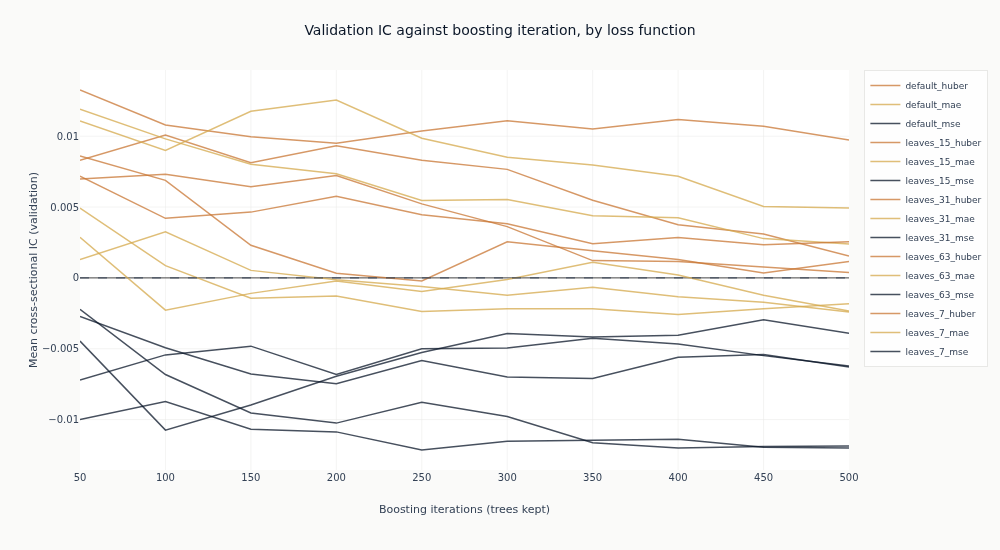

In [10]:
curves = catalog.filter("full_coverage").sort("config_name", "checkpoint_value")
objectives = {"mse": COLORS["blue"], "mae": COLORS["amber"], "huber": COLORS["copper"]}


def objective_of(name: str) -> str:
    """Read the loss function out of a declared configuration name."""
    return next((key for key in objectives if name.endswith(key)), "mse")


fig_curves = go.Figure()
for config_name in curves.get_column("config_name").unique(maintain_order=True):
    series = curves.filter(pl.col("config_name") == config_name)
    fig_curves.add_trace(
        go.Scatter(
            x=series.get_column("checkpoint_value").to_list(),
            y=series.get_column("ic_mean").to_list(),
            mode="lines",
            name=config_name,
            line=dict(color=objectives[objective_of(config_name)], width=1.5),
            opacity=0.75,
        )
    )
fig_curves.add_hline(y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
fig_curves.update_layout(
    title="Validation IC against boosting iteration, by loss function",
    height=550,
    width=1000,
    margin=dict(t=70),
    legend=dict(font=dict(size=9)),
)
fig_curves.update_xaxes(title_text="Boosting iterations (trees kept)")
fig_curves.update_yaxes(title_text="Mean cross-sectional IC (validation)")
show_plotly_with_alt(
    fig_curves,
    "Line chart of mean validation information coefficient against boosting iteration, one line "
    "per configuration, coloured by loss function: blue for squared error, amber for absolute "
    "error, copper for Huber. A dashed line marks zero. The colours divide across it: the copper "
    "Huber lines run above zero for most of the range, the blue squared-error lines below it, "
    "and the amber absolute-error lines cross back and forth near it. Most lines reach their "
    "highest point in the first fifth of the range and drift afterwards.",
)

### Whether the loss function is what separates them

The curves are coloured by objective because that is the axis with a mechanism behind it. If
heavy tails are steering the squared-error fits, the three colours should separate, and they
should separate more as trees are added, since each additional tree is fitted to the residuals
the previous ones left.

The chart below drops the checkpoint dimension by taking each configuration's final state, so
every configuration is compared at the same amount of training. That is the comparison that does
not require choosing anything after the fact.

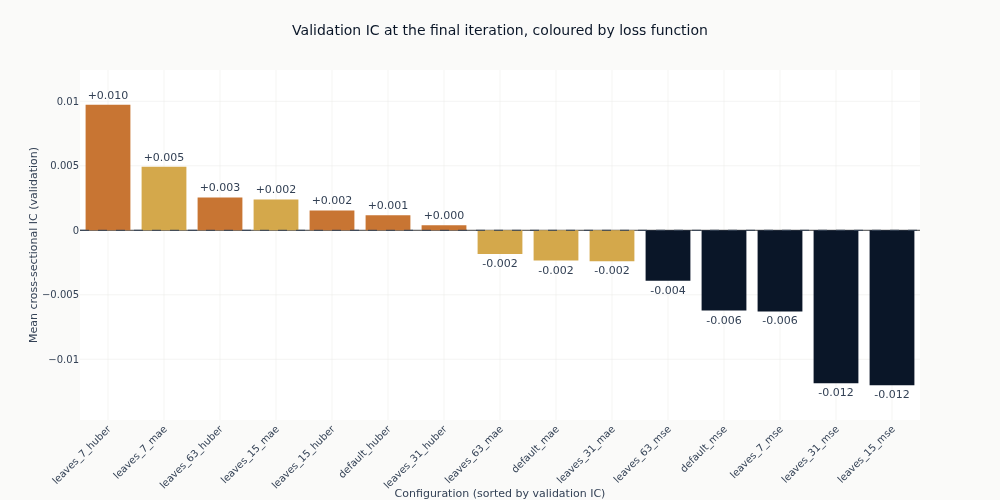

In [11]:
final_iteration = int(catalog.get_column("checkpoint_value").max())
final = (
    catalog.filter(pl.col("checkpoint_value") == final_iteration)
    .filter("full_coverage")
    .with_columns(objective=pl.col("config_name").map_elements(objective_of, return_dtype=pl.Utf8))
    .sort("ic_mean", descending=True)
)

fig_obj = go.Figure(
    go.Bar(
        x=final.get_column("config_name").to_list(),
        y=final.get_column("ic_mean").to_list(),
        marker_color=[objectives[value] for value in final.get_column("objective")],
        text=[f"{value:+.3f}" for value in final.get_column("ic_mean")],
        textposition="outside",
        cliponaxis=False,
    )
)
fig_obj.add_hline(y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
fig_obj.update_layout(
    title="Validation IC at the final iteration, coloured by loss function",
    height=500,
    width=1000,
    showlegend=False,
    margin=dict(t=70),
)
fig_obj.update_xaxes(title_text="Configuration (sorted by validation IC)", tickangle=-45)
fig_obj.update_yaxes(title_text="Mean cross-sectional IC (validation)")
show_plotly_with_alt(
    fig_obj,
    "Bar chart of mean validation information coefficient for every full-coverage configuration "
    "at its final boosting iteration, sorted descending and coloured by loss function, against a "
    "dashed zero line. The bars divide by colour rather than by leaf count: every copper Huber "
    "bar stands above the line at the left of the ranking, every blue squared-error bar hangs "
    "below it at the right, and the amber absolute-error bars sit between them across the zero "
    "line. Leaf count varies within each colour group without ordering it.",
)

### How much the checkpoint moves a configuration

One number per configuration: the range its IC covers across its own ten checkpoints. This is
the quantity that decides whether choosing a stopping point is a decision worth making carefully
or one being made by noise. A configuration whose IC varies more across its own training run
than the configurations vary among themselves is one where the checkpoint, not the model, is
doing the ranking.

In [12]:
spread = (
    curves.group_by("config_name")
    .agg(
        ic_min=pl.col("ic_mean").min(),
        ic_max=pl.col("ic_mean").max(),
        ic_final=pl.col("ic_mean").filter(pl.col("checkpoint_value") == final_iteration).first(),
    )
    .with_columns(checkpoint_range=pl.col("ic_max") - pl.col("ic_min"))
    .sort("checkpoint_range", descending=True)
)
across_configs = float(final.get_column("ic_mean").max() - final.get_column("ic_mean").min())
print(f"IC range across configurations at the final iteration: {across_configs:.4f}")
print(
    f"median IC range within one configuration: {spread.get_column('checkpoint_range').median():.4f}"
)
spread

IC range across configurations at the final iteration: 0.0217
median IC range within one configuration: 0.0069


config_name,ic_min,ic_max,ic_final,checkpoint_range
str,f64,f64,f64,f64
"""leaves_31_mse""",-0.012009,-0.00222,-0.011864,0.009788
"""leaves_15_mae""",0.002394,0.011913,0.002394,0.009519
"""default_huber""",-0.000217,0.008602,0.001158,0.008819
"""leaves_15_huber""",0.00154,0.010076,0.00154,0.008536
"""leaves_63_mse""",-0.010746,-0.002947,-0.003916,0.007799
…,…,…,…,…
"""leaves_63_huber""",0.002344,0.007189,0.002548,0.004845
"""leaves_7_mse""",-0.007476,-0.00273,-0.00629,0.004747
"""leaves_7_huber""",0.009501,0.013263,0.009729,0.003762


## 5. What to notice

**The objectives separate, in the predicted order, and almost without overlap.** Every
squared-error configuration ends training on the wrong side of zero. Every Huber configuration
ends on the right side of it. Absolute error sits between them and straddles zero. The
separation is by loss function and not by capacity: the deepest and shallowest settings appear
at both ends of the ranking, while the colour of a bar predicts which half of the table it is
in. This is the answer to the question `06_linear` could only ask, and it is as clean as this
kind of comparison gets.

**The mechanism is the payoff shape, and the linear result is consistent with it.** A short
straddle earns at most the premium and can lose many multiples of it, so the label's mass sits
in a narrow band with a long tail on one side. Squared error weights an observation by the square
of its error, so a handful of expiries where the position lost heavily dominate what every
successive tree is fitted to - and getting those few right does nothing for a rank correlation,
which only asks whether the positions were ordered correctly. Huber caps how much any one
observation can pull, spends its capacity on the body of the distribution where most of the
ranking is decided, and comes out positive. The linear model in `06_linear` minimizes squared
error and finished close to where the squared-error configurations here finish, which is what
this reading predicts.

**The lesson generalizes past this case study.** Nothing above is specific to options. It applies
whenever the target has a long tail and the metric is rank-based, which describes most of the
labels in this book. **Choosing a loss function is choosing which errors the model is paid to
reduce, and if that choice does not match the metric the result is judged on, the model will
spend its capacity where the metric gives nothing back.** The usual remedies - winsorizing the
label, ranking it, or changing the objective - are the same intervention seen from three sides.

**Read the magnitudes with the sample in mind.** The positive numbers are small, they rest on
two validation folds covering 2019 and 2020, and the second of those is one event that a
short-volatility position exists to be paid for. A single regime can move a two-fold average a
long way. What the results support is the ordering of the objectives, which is consistent and
has a mechanism behind it; what they do not support is any particular configuration's value.

**Most configurations peak early.** Twelve of the fifteen reach their highest IC within the first
fifth of the declared iterations and drift afterwards. Combined with the objective finding, the
picture is of a model that extracts what is available quickly and then spends the remaining
iterations fitting the tail of the training window - which is precisely what squared error
rewards it for doing, and part of why that objective ends up furthest below zero.

**The checkpoint is a smaller dial than the objective here.** Across the fifteen configurations
at fixed training length the IC spans about three times what a single configuration spans across
its own ten checkpoints. That is the unusual case: in this case study the thing that decides the
answer is a declared modelling choice rather than where training happened to stop. It does not
make the leading row safe to quote - it is still the maximum of 150 numbers - but it does mean
the pattern in the second chart is the result rather than an artifact of stopping points.

**None of this selects anything.** IC measures whether predictions rank positions correctly, not
whether a strategy trading them makes money after costs. That gap is unusually wide for short
volatility: a strategy can rank correctly and still be ruined by the tail it ranked, because the
metric treats a large loss and a small one as adjacent while the profit and loss does not.
Selection is on validation backtest Sharpe over the population just published, in
[`12_backtest`](12_backtest.ipynb), where the checkpoint is part of what is selected.

**Known limitations.** Two folds, one of which contains a volatility event that dominates the
tail behaviour being compared. The IC is an average of daily rank correlations across the
positions live on each date, with no adjustment for the overlap between straddles held at the
same time, so it is a diagnostic rather than a test. The grid varies capacity and loss at a fixed
learning rate. And the fills are at the next close, because the option chain carries end-of-
session quotes only - a constraint of the data described in [`02_labels`](02_labels.ipynb).

**Next**: [`08_tabular_dl`](08_tabular_dl.ipynb) fits a neural network to the same rows. It is
trained by gradient descent on a loss the notebook chooses, so the comparison above can be run
again in a different model class - and if the tails are what separates the objectives here, the
same ordering should appear there.